# LocoSense — Phase 4: Evaluation & SHAP Explainability

**Input:** `models/xgb_model.pkl`, `data/processed/test.csv`  
**Output:** SHAP plots saved to `reports/figures/`

| Step | Task |
|------|------|
| 1 | Imports |
| 2 | Load model + test data |
| 3 | Full evaluation metrics + plots |
| 4 | Compute SHAP values |
| 5 | SHAP summary plot |
| 6 | SHAP bar plot — top 10 features |
| 7 | SHAP beeswarm plot |
| 8 | SHAP waterfall — single loco |
| 9 | SHAP dependence plots |
| 10 | Risk category assignment + fleet snapshot |
| 11 | explain_loco() function for Phase 5 |
| 12 | Save all outputs |

---
## Cell 1 — Imports

In [81]:
import sys, warnings, json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import joblib
from pathlib import Path
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120,'savefig.bbox':'tight'})

NOTEBOOK_DIR= Path().resolve()
ROOT = NOTEBOOK_DIR
PROCESSED_DIR = ROOT / 'data' / 'processed'
MODELS_DIR= ROOT / 'models'
FIGURES_DIR= ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
for f in ['xgb_model.pkl', 'scaler.pkl', 'model_meta.json']:
    assert (MODELS_DIR / f).exists(), f'Missing {f} — run 03_model_training.ipynb first'

print(f'Python : {sys.version.split()[0]}')
print(f'SHAP   : {shap.__version__}')
print(f'numpy  : {np.__version__}')

Python : 3.11.3
SHAP   : 0.51.0
numpy  : 2.4.6


---
## Cell 2 — Load model + test data

In [82]:
xgb_model = joblib.load(MODELS_DIR / 'xgb_model.pkl')
with open(MODELS_DIR / 'model_meta.json') as f:
    meta = json.load(f)
FEATURE_COLS = meta['feature_cols']
TARGET       = meta['target_col']
THRESHOLD    = meta['threshold']
test_df  = pd.read_csv(PROCESSED_DIR / 'test.csv')
train_df = pd.read_csv(PROCESSED_DIR / 'train.csv')
missing = [c for c in FEATURE_COLS if c not in test_df.columns]
if missing:
    print(f'WARNING: {len(missing)} feature cols missing from test.csv: {missing[:5]}')
    FEATURE_COLS = [c for c in FEATURE_COLS if c in test_df.columns]

X_test = test_df[FEATURE_COLS]
y_test = test_df[TARGET]
X_train = train_df[FEATURE_COLS]

SENSOR_COLS = [
    'engine temp   (C)', 'oil pressure (bar)', 'vibration    (mms)', 'fuel efficiency (%)',
    'coolant temp (C)', 'bearing temp  (C)', 'RPM', 'exhaust temp (C)',
    'turbo pressure (bar)', 'load factor (%)', 'battery voltage (V)', 'brake pressure (bar)',
]

def get_risk(prob):
    if prob < 0.30:return 'Low','#1D9E75'
    elif prob < 0.50: return 'Medium','#EF9F27'
    elif prob < 0.75: return 'High','#D85A30'
    else:return 'Critical', '#E24B4A'

def clean_name(name):
    return (name
        .replace('_roll5_mean',' (5 cycle mean)')
        .replace('_roll10_mean',' (10 cycle mean)')
        .replace('_roll5_std',' (5 cycle std)')
        .replace('_roll10_std',' (10 cycle std)')
        .replace('_lag1', ' (prev cycle)')
        .replace('_', ' ').title()
    )

print(f'Model: XGBoost {xgb_model.n_estimators} estimators')
print(f'Features: {len(FEATURE_COLS)}')
print(f'Test rows: {len(X_test):,}  ({y_test.mean()*100:.1f}% failure)')
print(f'Threshol: {THRESHOLD}')

Model: XGBoost 400 estimators
Features: 87
Test rows: 1,144  (50.3% failure)
Threshol: 0.5


---
## Cell 3 — Full evaluation metrics + plots

In [83]:
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt

print(matplotlib.get_backend())

inline


FINAL MODEL PERFORMANCE
R²   : 0.9998
MAE  : 0.0031
RMSE : 0.0044


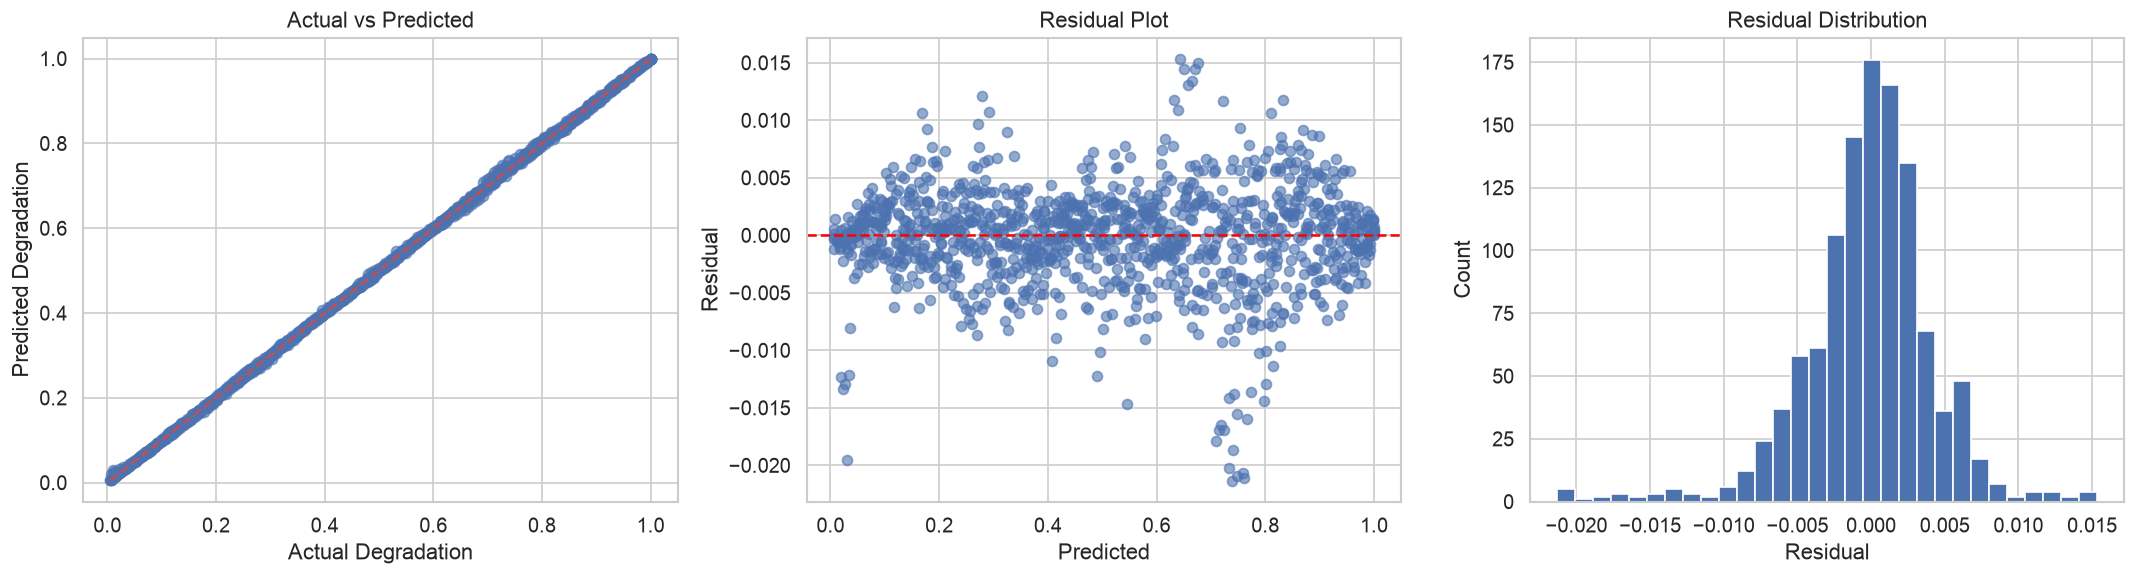

In [84]:
from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    r2_score
)

import matplotlib.pyplot as plt
import numpy as np

# Predictions
test_preds = xgb_model.predict(X_test).clip(0, 1)

# Metrics
rmse = root_mean_squared_error(y_test, test_preds)
mae = mean_absolute_error(y_test, test_preds)
r2 = r2_score(y_test, test_preds)

print("=" * 50)
print("FINAL MODEL PERFORMANCE")
print("=" * 50)
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")

# ===========================================
# Plots
# ===========================================

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# -----------------------------
# Actual vs Predicted
# -----------------------------
axes[0].scatter(y_test, test_preds, alpha=0.6)

mn = min(y_test.min(), test_preds.min())
mx = max(y_test.max(), test_preds.max())

axes[0].plot([mn, mx], [mn, mx], 'r--')

axes[0].set_title("Actual vs Predicted")
axes[0].set_xlabel("Actual Degradation")
axes[0].set_ylabel("Predicted Degradation")

# -----------------------------
# Residual Plot
# -----------------------------
residuals = y_test - test_preds

axes[1].scatter(test_preds, residuals, alpha=0.6)

axes[1].axhline(0, color="red", linestyle="--")

axes[1].set_title("Residual Plot")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residual")

# -----------------------------
# Residual Histogram
# -----------------------------
axes[2].hist(residuals, bins=30)

axes[2].set_title("Residual Distribution")
axes[2].set_xlabel("Residual")
axes[2].set_ylabel("Count")

plt.tight_layout()

plt.savefig(FIGURES_DIR / "evaluation_plots.png", dpi=300)

fig.canvas.draw()

plt.show(block=True)

In [85]:
# test_proba = xgb_model.predict_proba(X_test)[:, 1]
# test_preds = (test_proba >= THRESHOLD).astype(int)

# roc_auc = roc_auc_score(y_test, test_proba)
# ap= average_precision_score(y_test, test_proba)
# f1= f1_score(y_test, test_preds)
# prec= precision_score(y_test, test_preds)
# rec= recall_score(y_test, test_preds)

# print(f'ROCAUC: {roc_auc:.4f}')
# print(f'Avg Precision : {ap:.4f}')
# print(f'F1 Score: {f1:.4f}')
# print(f'Precision: {prec:.4f}')
# print(f'Recall: {rec:.4f}')
# print()
# print(classification_report(y_test, test_preds,
#       target_names=['No failure', 'Failure']))

# fig = plt.figure(figsize=(16, 5))
# gs  = gridspec.GridSpec(1, 3)

# ax1 = fig.add_subplot(gs[0])
# fpr, tpr, _ = roc_curve(y_test, test_proba)
# ax1.plot(fpr, tpr, color='#378ADD', lw=2, label=f'AUC = {roc_auc:.3f}')
# ax1.plot([0,1],[0,1],'--', color='gray', lw=1)
# ax1.fill_between(fpr, tpr, alpha=0.08, color='#378ADD')
# ax1.set_xlabel('False Positive Rate')
# ax1.set_ylabel('True Positive Rate')
# ax1.set_title('ROC Curve', fontweight='bold')
# ax1.legend()

# ax2 = fig.add_subplot(gs[1])
# prec_c, rec_c, _ = precision_recall_curve(y_test, test_proba)
# ax2.plot(rec_c, prec_c, color='#1D9E75', lw=2, label=f'AP = {ap:.3f}')
# ax2.axhline(y_test.mean(), color='gray', linestyle='--', lw=1,
#             label=f'Baseline = {y_test.mean():.2f}')
# ax2.set_xlabel('Recall')
# ax2.set_ylabel('Precision')
# ax2.set_title('Precision Recall Curve', fontweight='bold')
# ax2.legend()

# ax3 = fig.add_subplot(gs[2])
# cm = confusion_matrix(y_test, test_preds)
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#             xticklabels=['No failure','Failure'],
#             yticklabels=['No failure','Failure'],
#             ax=ax3, annot_kws={'size': 13})
# ax3.set_xlabel('Predicted')
# ax3.set_ylabel('Actual')
# ax3.set_title('Confusion Matrix', fontweight='bold')

# plt.suptitle('LocoSense Test Set Evaluation', fontsize=13, fontweight='bold')
# plt.tight_layout()
# plt.savefig(FIGURES_DIR / 'phase4 evaluation.png')
# plt.show()

---
## Cell 4 — Compute SHAP values

In [86]:
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test)
if hasattr(shap_values, 'values'):
    sv = shap_values.values
else:
    sv = shap_values

if sv.ndim == 3:
    sv = sv[:, :, 1]

print(f'SHAP values shape : {sv.shape}')
print(f'Expected value: {explainer.expected_value if not hasattr(explainer.expected_value, "__len__") else explainer.expected_value[1]:.4f}')

mean_shap = pd.DataFrame({
    'feature'  : FEATURE_COLS,
    'mean_shap': np.abs(sv).mean(axis=0)
}).sort_values('mean_shap', ascending=False).reset_index(drop=True)

print(f'\nfeatures by meanSHAP:')
print(mean_shap.head(5).to_string(index=False))

SHAP values shape : (1144, 87)
Expected value: 0.5033

features by meanSHAP:
                         feature  mean_shap
                              RU   0.139837
                           cycle   0.130339
  vibration    (mms)_roll10_mean   0.011325
turbo pressure (bar)_roll10_mean   0.008668
  oil pressure (bar)_roll10_mean   0.006640


---
## Cell 5 — SHAP Summary plot

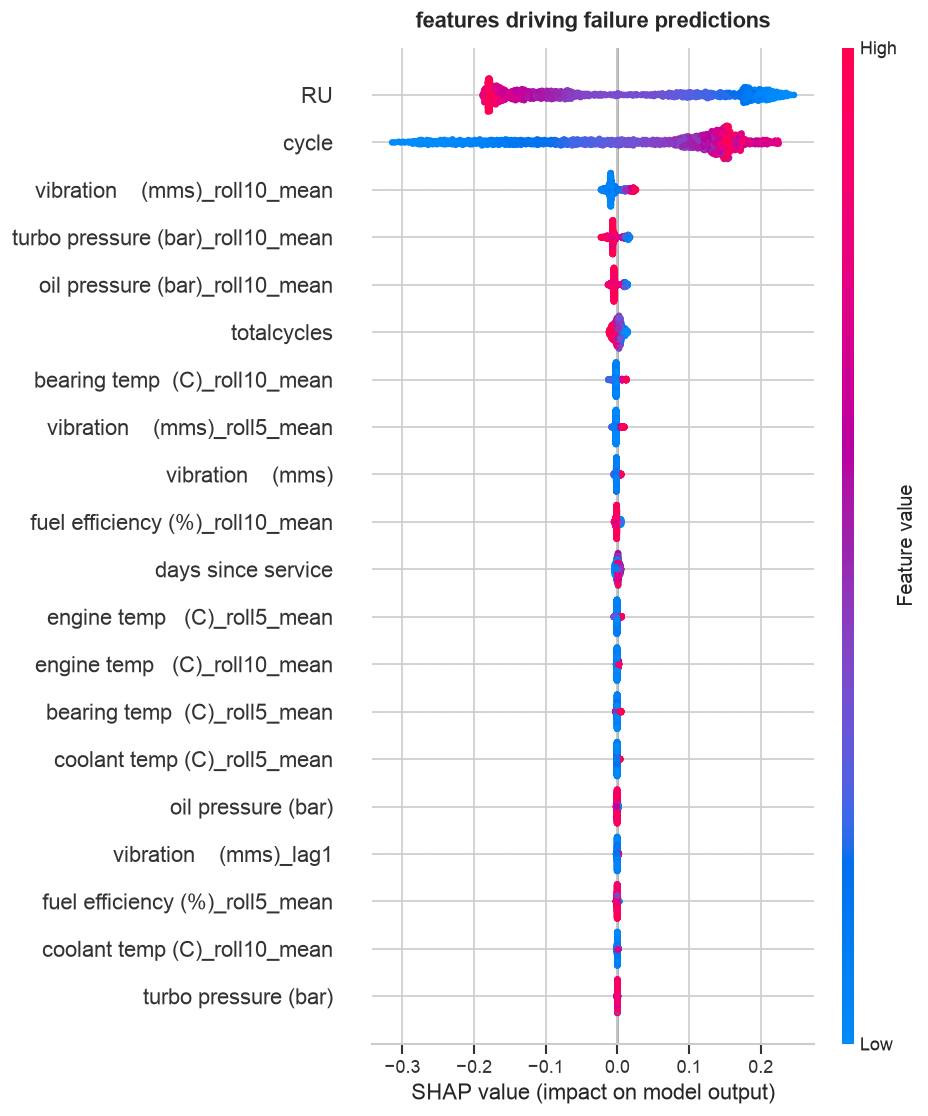

In [87]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    sv,
    X_test,
    feature_names = FEATURE_COLS,
    max_display   = 20,
    show          = False
)
plt.title('features driving failure predictions',
          fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap summary.png', bbox_inches='tight')
plt.show()

---
## Cell 6 — SHAP Bar plot — top 10 drivers

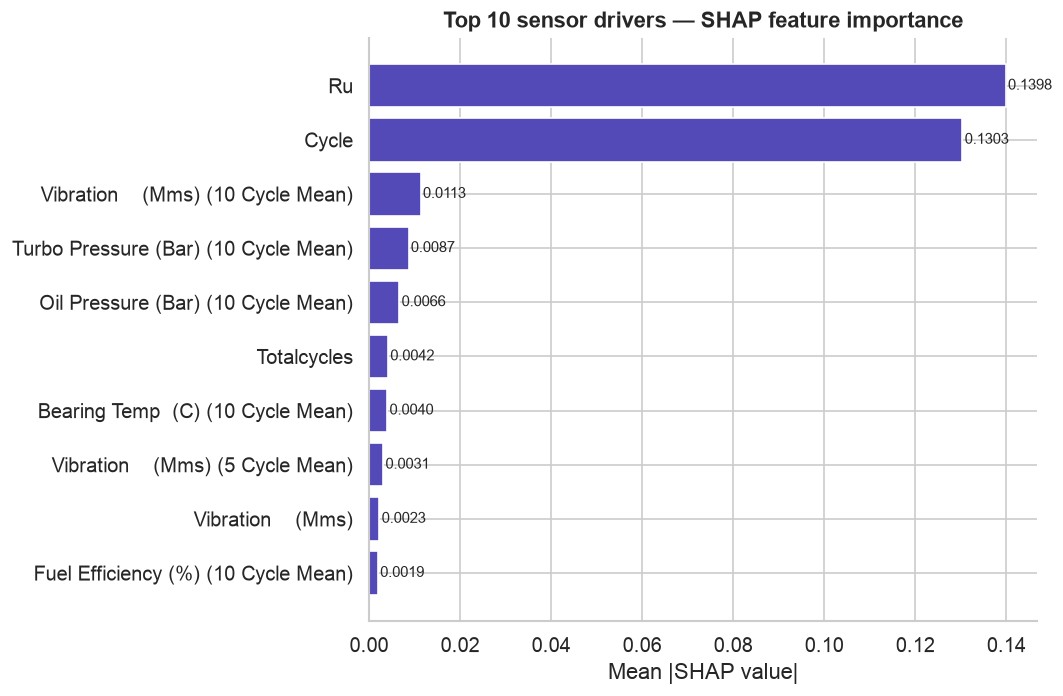

Top 10:
  RU                                        0.1398
  cycle                                     0.1303
  vibration    (mms)_roll10_mean            0.0113
  turbo pressure (bar)_roll10_mean          0.0087
  oil pressure (bar)_roll10_mean            0.0066
  totalcycles                               0.0042
  bearing temp  (C)_roll10_mean             0.0040
  vibration    (mms)_roll5_mean             0.0031
  vibration    (mms)                        0.0023
  fuel efficiency (%)_roll10_mean           0.0019


In [88]:
top10        = mean_shap.head(10)
top10_labels = [clean_name(f) for f in top10['feature']]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(
    top10_labels[::-1],
    top10['mean_shap'].values[::-1],
    color='#534AB7', edgecolor='white'
)
for bar, val in zip(bars, top10['mean_shap'].values[::-1]):
    ax.text(bar.get_width() + 0.0005,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Top 10 sensor drivers — SHAP feature importance', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shaptop10 bar.png')
plt.show()

print('Top 10:')
for _, row in top10.iterrows():
    print(f'  {row["feature"]:<40}  {row["mean_shap"]:.4f}')

---
## Cell 7 — SHAP Beeswarm plot

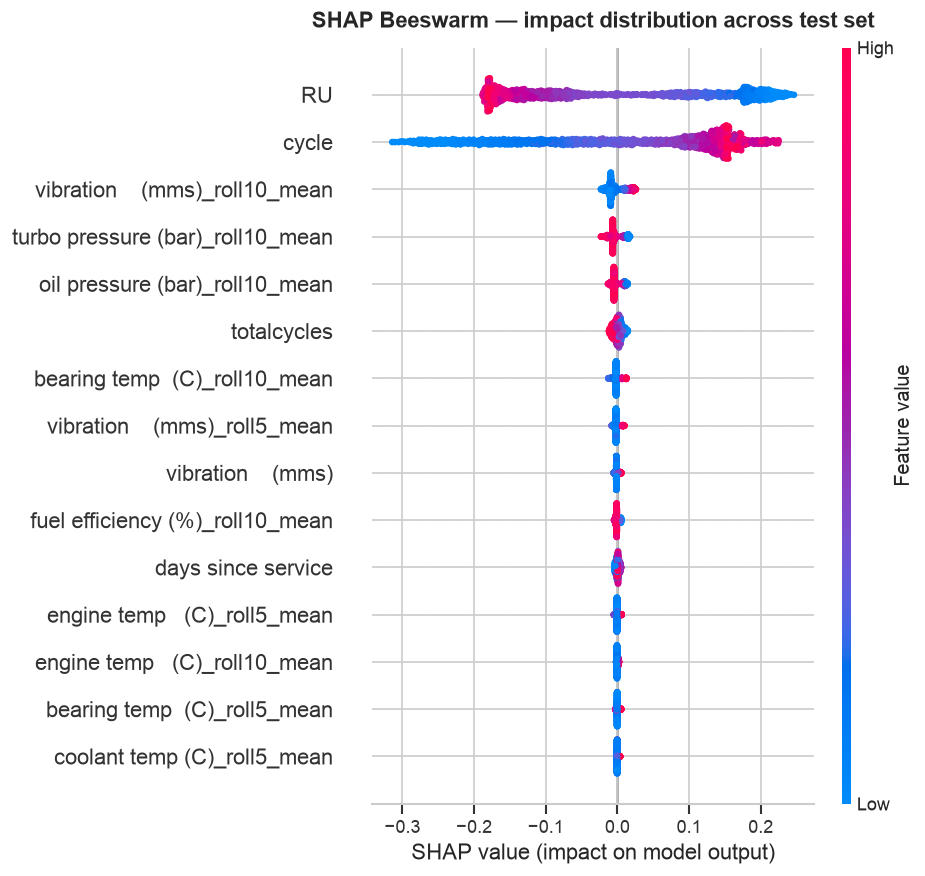

In [89]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    sv,
    X_test,
    feature_names = FEATURE_COLS,
    plot_type     = 'dot',
    max_display   = 15,
    show          = False
)
plt.title('SHAP Beeswarm — impact distribution across test set',
          fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap beeswarm.png', bbox_inches='tight')
plt.show()

---
## Cell 8 — SHAP Waterfall — why is this loco High risk?

Loco : WAP5-1011
Actuallabel: 1.0  (FAILURE)
Failure prob : 1.0000
Risk category: Critical


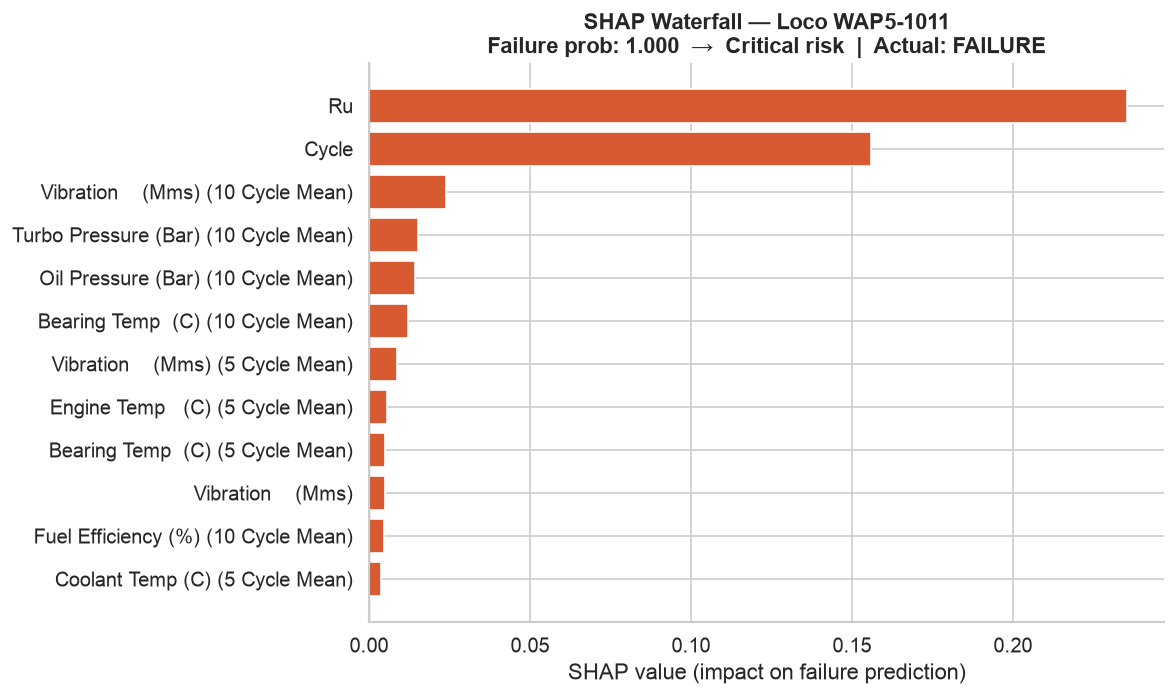

In [90]:
true_positives = np.where((y_test.values == 1) & (test_preds == 1))[0]
sample_idx = (
    true_positives[np.argmax(test_preds[true_positives])]
    if len(true_positives) > 0
    else int(np.argmax(test_proba))
)

prob       = test_preds[sample_idx]
actual     = y_test.values[sample_idx]
risk, _    = get_risk(prob)
loco_id_val= test_df['loco id'].values[sample_idx] if 'loco id' in test_df.columns else 'Unknown'

print(f'Loco : {loco_id_val}')
print(f'Actuallabel: {actual}  ({"FAILURE" if actual==1 else "No failure"})')
print(f'Failure prob : {prob:.4f}')
print(f'Risk category: {risk}')


sample_shap   = sv[sample_idx]
sample_feat   = X_test.iloc[sample_idx]
base_val      = (explainer.expected_value
                 if not hasattr(explainer.expected_value, '__len__')
                 else explainer.expected_value[1])

waterfall_df = pd.DataFrame({
    'feature'  : FEATURE_COLS,
    'shap_val' : sample_shap,
    'feat_val' : sample_feat.values
})
waterfall_df['abs'] = waterfall_df['shap_val'].abs()
top_wf = waterfall_df.sort_values('abs', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 6))
colors  = ['#D85A30' if v > 0 else '#1D9E75' for v in top_wf['shap_val'].values[::-1]]
ax.barh(
    [clean_name(f) for f in top_wf['feature'].values[::-1]],
    top_wf['shap_val'].values[::-1],
    color=colors, edgecolor='white'
)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('SHAP value (impact on failure prediction)')
ax.set_title(
    f'SHAP Waterfall — Loco {loco_id_val}\n'
    f'Failure prob: {prob:.3f}  →  {risk} risk  |  '
    f'Actual: {"FAILURE" if actual==1 else "No failure"}',
    fontweight='bold'
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap waterfall sample.png', bbox_inches='tight')
plt.show()

---
## Cell 9 — SHAP Dependence plots (top 3 sensors)

Top 3 features: ['RU', 'cycle', 'vibration    (mms)_roll10_mean']


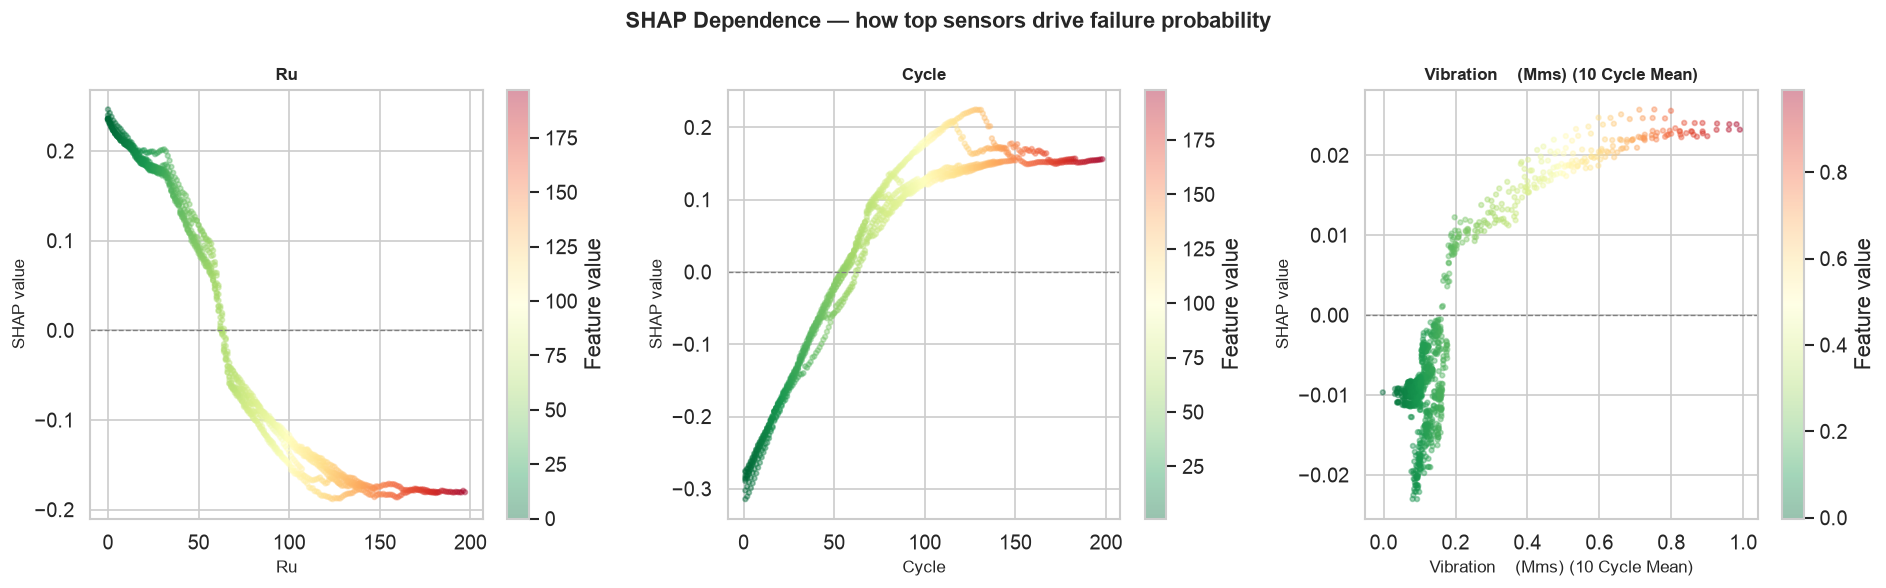

In [91]:
top3 = mean_shap.head(3)['feature'].tolist()
print(f'Top 3 features: {top3}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, feature in enumerate(top3):
    feat_idx  = FEATURE_COLS.index(feature)
    shap_vals = sv[:, feat_idx]
    feat_vals = X_test[feature].values

    sc = axes[i].scatter(
        feat_vals, shap_vals,
        c=feat_vals, cmap='RdYlGn_r',
        alpha=0.4, s=8, rasterized=True
    )
    axes[i].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axes[i].set_xlabel(clean_name(feature), fontsize=10)
    axes[i].set_ylabel('SHAP value', fontsize=10)
    axes[i].set_title(f'{clean_name(feature)}', fontweight='bold', fontsize=10)
    plt.colorbar(sc, ax=axes[i], label='Feature value')

plt.suptitle('SHAP Dependence — how top sensors drive failure probability',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_dependence.png')
plt.show()

---
## Cell 10 — Risk category assignment + fleet snapshot

In [92]:
print(test_results.columns.tolist())

['loco id', 'cycle', 'failure prob', 'predicted label', 'actual label', 'risk category']


Risk distribution (test set):
risk category
Low         338
Medium      228
High        283
Critical    295

Fleet snapshot 8 test locos:
  loco id  failure prob risk category  actual label
WAP5-1011      1.000000      Critical           1.0
WAG9-1048      0.999869      Critical           1.0
WAG9-1015      0.999605      Critical           1.0
WAP5-1010      0.999561      Critical           1.0
WAP5-1028      0.999303      Critical           1.0
WDG4-1046      0.998748      Critical           1.0
WAP5-1036      0.998693      Critical           1.0
WAP5-1039      0.998602      Critical           1.0


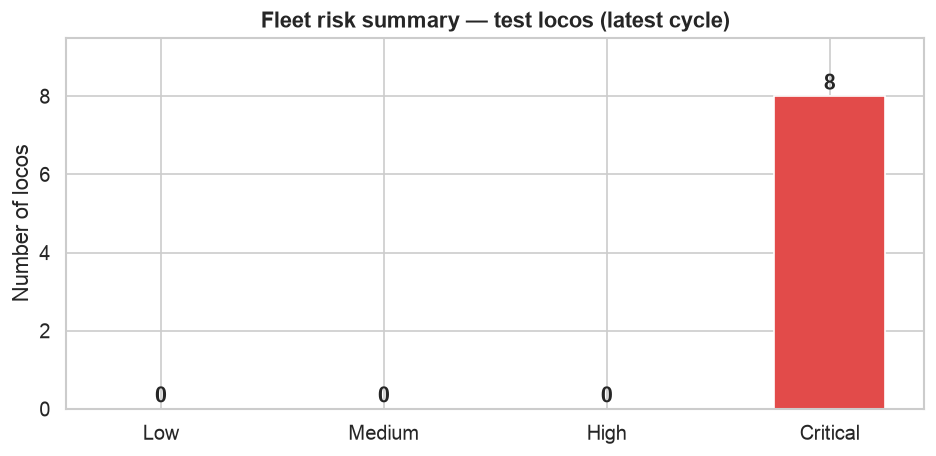

In [93]:
test_results = test_df[['loco id','cycle']].copy() if 'loco id' in test_df.columns else test_df[['cycle']].copy()
test_results['failure prob']    = test_preds
test_results['predicted label'] = test_preds
test_results['actual label']    = y_test.values
test_results['risk category']   = pd.cut(
    test_preds,
    bins   = [0.0, 0.30, 0.50, 0.75, 1.01],
    labels = ['Low', 'Medium', 'High', 'Critical']
)

print('Risk distribution (test set):')
print(test_results['risk category']
      .value_counts()
      .reindex(['Low','Medium','High','Critical'])
      .to_string())

if 'loco id' in test_results.columns:
    latest = (test_results
              .sort_values('cycle')
              .groupby('loco id')
              .last()
              .reset_index()
              .sort_values('failure prob', ascending=False))

    print(f'\nFleet snapshot {len(latest)} test locos:')
    print(latest[['loco id','failure prob','risk category','actual label']]
          .to_string(index=False))

    risk_counts = (latest['risk category']
                   .value_counts()
                   .reindex(['Low','Medium','High','Critical'])
                   .fillna(0).astype(int))
    colors = ['#1D9E75','#EF9F27','#D85A30','#E24B4A']

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(risk_counts.index, risk_counts.values, color=colors, width=0.5)
    for bar, val in zip(bars, risk_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.05,
                str(val), ha='center', va='bottom', fontweight='bold')
    ax.set_title('Fleet risk summary — test locos (latest cycle)', fontweight='bold')
    ax.set_ylabel('Number of locos')
    ax.set_ylim(0, risk_counts.max() + 1.5)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'fleet_risk_summary.png')
    plt.show()

In [94]:
print('loco id' in test_df.columns)

True


---
## Cell 11 — explain_loco() — reused in Phase 5 Flask API

In [95]:
def explain_loco(loco_id, top_n=6):
    if 'loco id' not in test_df.columns:
        return None
    loco_rows = test_df[test_df['loco id'] == loco_id]
    if loco_rows.empty:
        print(f'{loco_id} not in test set')
        return None

    latest_row = loco_rows.sort_values('cycle').iloc[[-1]]
    X_loco     = latest_row[FEATURE_COLS]
    pred = float(xgb_model.predict(X_loco)[0])

    pred = max(0.0, min(1.0, pred))
    risk, _    = get_risk(pred)

    shap_loco  = explainer(X_loco)
    sv_loco    = shap_loco.values[0] if hasattr(shap_loco, 'values') else shap_loco[0]
    if sv_loco.ndim == 2:
        sv_loco = sv_loco[:, 1]

    shap_df = pd.DataFrame({
        'feature'    : FEATURE_COLS,
        'shap_value' : sv_loco,
        'feature_val': X_loco.values[0]
    })
    shap_df['abs_shap']  = shap_df['shap_value'].abs()
    top_drivers          = shap_df.sort_values('abs_shap', ascending=False).head(top_n)
    print(f'Loco : {loco_id}')
    print(f'Failure prob  : {pred:.4f}')
    print(f'Risk category : {risk}')
    print(f'\nTop {top_n} drivers:')
    for _, row in top_drivers.iterrows():
        direction = '↑ increases risk' if row['shap_value'] > 0 else '↓ decreases risk'
        print(f'  {row["feature"]:<35}  {row["shap_value"]:+.4f}  {direction}')

    return {
        'loco id'      : loco_id,
        'failure_prob' : round(pred, 4),
        'risk_category': risk,
        'top_drivers'  : top_drivers[['feature','shap_value','feature_val']].to_dict('records')
    }

# Test with first loco in test set
if 'loco id' in test_df.columns:
    result = explain_loco(test_df['loco id'].iloc[0])

Loco : WAG9-1015
Failure prob  : 0.9996
Risk category : Critical

Top 6 drivers:
  RU                                   +0.2357  ↑ increases risk
  cycle                                +0.1527  ↑ increases risk
  vibration    (mms)_roll10_mean       +0.0223  ↑ increases risk
  turbo pressure (bar)_roll10_mean     +0.0152  ↑ increases risk
  bearing temp  (C)_roll10_mean        +0.0122  ↑ increases risk
  oil pressure (bar)_roll10_mean       +0.0116  ↑ increases risk


---
## Cell 12 — Save outputs + summary

In [96]:

pd.DataFrame(sv, columns=FEATURE_COLS).to_csv(
    PROCESSED_DIR / 'shap_values_test.csv', index=False
)

with open(MODELS_DIR / 'shap_top_features.json', 'w') as f:
    json.dump(
        mean_shap.head(10)[['feature','mean_shap']].to_dict('records'),
        f, indent=2
    )

print(f'  RMSEC        : {rmse:.4f}')
print(f'  MAE       : {mae:.4f}')
print(f'  R2_SORE      : {r2:.4f}')
print(f'  Top SHAP driver: {mean_shap.iloc[0]["feature"]}')

  RMSEC        : 0.0044
  MAE       : 0.0031
  R2_SORE      : 0.9998
  Top SHAP driver: RU
